# Data Workshop 1



**Instructors:** Argen Smith (PO), Sophie Wynn (CS), Tommy Stone (AOS)

## Before the Workshop

### Installations
We expect that you will have Conda and VS Code installed on your computer before attending the workshop. If you need help we will have **office hours** to help with installs and troubleshoot issues from 12:30pm - 1:25pm in Munk Lab 303 on 09/18. 

See the below website for instructions to install
1) [Python Installation with Conda](https://eldavenport.github.io/SIO-PythonEarthScience/)
2) [VSCode Installation](https://eldavenport.github.io/SIO-PythonEarthScience/installation/software_install/vscode_install.html)

### Github Repository

All notebooks can be found on the [Math Workshop Github](https://github.com/tgstone/sio-math-workshop/)


### Data
You can download the available datasets that we will used for the workshop from our [data folder on Google drive](https://drive.google.com/drive/folders/1csB0khdMHT0-xp3sEaG3N3kgKTbG-lbO?usp=drive_link). You will need your UCSD google account to access the site.

## 1) Python environment management and modules

Teacher: Argen Smith
TA: Sophie Wynn, Tommy Stone

## 2) Reading, Slicing and Plotting data 
Teacher: Sophie Wynn
TA: Argen Smith, Tommy Stone

## Reading, Slicing & Plotting Ocean Data
### xarray and pandas → cartopy/matplotlib/cmocean

---
## Part 1 — Reading Data, Slicing, with `xarray` and `pandas` 

### 1.1 Reading data files

**netCDF** (`.nc`) files are in a self-describing binary format that bundles the data *and* its
coordinates, units, and **metadata** in one file. `xarray` is the standard tool for reading them because
it keeps that structure intact (unlike loading straight into a bare NumPy array).

**CSV** (`csv`) file,  stands for comma-separated values, is a plain text file used to store table data like rows and columns. `Pandas` is the  standard tool for reading them. 

**How you'd read each dataset**

| Dataset |  format | How you'd open it |
|---|---|---|
| **SST** | netCDF, regular lat/lon grid | `xr.open_dataset(".nc")` | 
| **Chlorophyll** (CCE LTER) | csv, one row per sampling event | `pd.read_csv(".csv")` | 
| **SSH** | most likely: netCDF, regular lat/lon grid | `?` | 
| **Tide gauge** | ? | `?` |



In [2]:
# this segment of code is for loading libraries
import pandas as pd
import xarray as xr
import geopandas as gpd

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean

## 1.1 Xarray

In [3]:
#open the sea surface temperature dataset using xarray
ds_sst = xr.open_dataset("/Users/sophiewynn/Desktop/lesson plans/MathWorkShop/sst_workshop.nc")
ds_sst

<xarray.Dataset> Size: 36MB
Dimensions:  (lat: 89, lon: 180, time: 559)
Coordinates:
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 4kB 1980-01-01 1980-02-01 ... 2026-07-01
Data variables:
    sst      (time, lat, lon) float32 36MB ...

### File formats, and meta data

- **Data variables** —here just `sst`, but a file could hold several.

A `Dataset` is a container of one or more `DataArray`s that all share coordinates. Pulling out a
single variable — `ds.sst` — gives you a `DataArray`, which is the thing you'll slice and plot most
of the time.

In [6]:
sst = ds_sst["sst"]     # now sst is a DataArray object, which is a single variable from the dataset
#print(sst)
print()
print("units:", sst.attrs.get("units"))
#print("long name:", sst.attrs.get("long_name"))
#print("source:", sst.attrs.get("dataset"))


units: degC


### 1.2 Slicing and selecting

`xarray` lets you select data **by label** (`.sel`) and of by integer position (`.isel`). When using `.sel` you type in the variable or coordinate and what you are looking for, not the indice

In [8]:
# Select the data for January 2020
jan2020 = ds_sst.sel(time="2020-01-01")
jan2020

<xarray.Dataset> Size: 65kB
Dimensions:  (lat: 89, lon: 180)
Coordinates:
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
    time     datetime64[ns] 8B 2020-01-01
Data variables:
    sst      (lat, lon) float32 64kB ...

In [9]:
# a time range
recent = ds_sst.sel(time=slice("2015-01-01", "2020-12-31"))
recent 

<xarray.Dataset> Size: 5MB
Dimensions:  (lat: 89, lon: 180, time: 72)
Coordinates:
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 576B 2015-01-01 2015-02-01 ... 2020-12-01
Data variables:
    sst      (time, lat, lon) float32 5MB ...

In [ ]:
# selecting  or grouping by time it season
djf = ds_sst.sel(time=ds_sst["time.season"] == "DJF")   # all Dec/Jan/Feb months, any year
# take the average sst of all the DJF months
djf_mean = djf.mean(dim="time")
djf_mean

In [18]:
# you can also use the groupby method to group by season and then take the mean
seasonal_mean = ds_sst.groupby("time.season").mean(dim="time")
seasonal_mean

<xarray.Dataset> Size: 257kB
Dimensions:  (season: 4, lat: 89, lon: 180)
Coordinates:
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
Data variables:
    sst      (season, lat, lon) float32 256kB -1.8 -1.8 -1.8 ... nan nan nan

### Question: Can you select the  Niño 3.4 region which is between (-5-5, 190-240). This is used to track sst to monitor El Niño / La Niña?

In [11]:
#nino34_box = ?


nino34_box = ds_sst.sst.sel(lat=slice(5, -5), lon=slice(190, 240))


**Area-weighted means.** On a lat/lon grid, boxes near the poles cover much less real ocean
area than boxes near the equator, so a plain `.mean(["lat","lon"])` over-weights high latitudes. The
fix is to weight each row by `cos(latitude)` before averaging:

In [13]:
import numpy as np
weights = np.cos(np.deg2rad(nino34_box.lat))
nino34_index = nino34_box.weighted(weights).mean(dim=["lat", "lon"])
nino34_index

<xarray.DataArray 'sst' (time: 559)> Size: 2kB
array([27.087723, 26.979757, 27.316122, 27.758884, 28.015308, 27.938494,
       27.230425, 26.477413, 26.440502, 26.460802, 26.601553, 26.64585 ,
       26.18831 , 26.123468, 26.65929 , 27.296642, 27.361252, 27.265312,
       26.65053 , 26.320612, 26.520903, 26.416492, 26.292328, 26.401995,
       26.678118, 26.599176, 27.423162, 28.033892, 28.385727, 28.255865,
       27.6577  , 27.57601 , 28.204529, 28.693298, 28.6136  , 28.789663,
       28.883419, 28.688124, 28.665266, 28.773945, 28.839191, 28.276678,
       27.189827, 26.597141, 26.203362, 25.570133, 25.419136, 25.575058,
       25.878386, 26.569353, 26.776297, 27.145086, 27.198494, 26.824575,
       26.781422, 26.603504, 26.375423, 26.038363, 25.51839 , 25.259922,
       25.392313, 26.036531, 26.503597, 26.652508, 26.907919, 26.811264,
       26.549212, 26.293556, 26.01578 , 26.227144, 26.32571 , 26.191793,
       25.892385, 26.06482 , 26.881714, 27.493721, 27.40791 , 27.424284,
       27.17766 , 27.168816, 27.239779, 27.514448, 27.7044  , 27.714104,
       27.67598 , 27.889465, 28.2721  , 28.399609, 28.558054, 28.641768,
       28.578287, 28.413252, 28.358025, 27.952196, 27.772263, 27.542849,
       27.451145, 27.036728, 27.38799 , 27.380682, 26.684141, 25.989532,
       25.55583 , 25.664465, 25.716589, 24.823757, 24.656416, 24.639172,
       24.59034 , 25.291838, 26.08573 , 26.751898, 27.065933, 27.142822,
       26.714785, 26.323334, 26.413351, 26.314657, 26.249388, 26.46425 ,
...
       26.134348, 26.681747, 27.32713 , 28.031487, 28.291162, 28.062868,
       27.551317, 26.704487, 26.290203, 26.154354, 25.745375, 25.612225,
       25.573965, 25.98431 , 26.497837, 27.32192 , 27.740665, 27.787521,
       27.435375, 26.96744 , 27.204218, 27.632767, 27.62422 , 27.49655 ,
       27.210815, 27.487299, 28.110186, 28.456547, 28.499243, 28.189072,
       27.653612, 26.909607, 26.764008, 27.213615, 27.237473, 27.128824,
       27.159166, 27.135008, 27.776552, 28.191046, 27.664125, 27.39275 ,
       26.996828, 26.271444, 25.892395, 25.467934, 25.289114, 25.452389,
       25.553785, 25.760168, 26.494886, 27.106337, 27.47458 , 27.445433,
       26.899677, 26.32029 , 26.161402, 25.772812, 25.756062, 25.535282,
       25.600288, 25.868153, 26.31618 , 26.706886, 26.817638, 26.968536,
       26.586575, 25.874804, 25.639412, 25.7177  , 25.792662, 25.742111,
       25.8346  , 26.302967, 27.18393 , 27.961428, 28.396135, 28.563614,
       28.313799, 28.204784, 28.316853, 28.437904, 28.727358, 28.633078,
       28.367107, 28.2853  , 28.424322, 28.609297, 28.176764, 27.912195,
       27.349144, 26.746483, 26.469118, 26.458813, 26.467201, 26.015436,
       25.815336, 26.332958, 27.302248, 27.684994, 27.803028, 27.66202 ,
       27.1506  , 26.492561, 26.246958, 26.216991, 26.006536, 25.928497,
       25.970411, 26.492887, 27.285149, 28.127031, 28.840485, 29.269   ,
       29.246767], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1980-01-01 1980-02-01 ... 2026-07-01

**Climatology and anomaly.** Two of the most common operations on any Earth-science time
series: the *climatology* is the typical seasonal cycle;
the *anomaly* is how far a given month (year etc) departs from its own climatological month (year etc). 

In [14]:
climatology_nino34 = nino34_index.groupby("time.month").mean("time")     # 12 values: typical Jan..Dec
nino34_anom = nino34_index.groupby("time.month") - climatology_nino34     # same length as the input series

### Question: Can you also calculate the climatology and anomalies for the full global fieldinstead of just the Niño 3.4 region?

### 1.3 Quick plotting with `xarray`

`xarray` objects have a built-in `.plot()` that infers the right
chart type from the shape of the data, it knows a 2-D `(lat, lon)` slice becomes a map, a 1-D `(time,)`
series becomes a line plot etc plus it also labels axes/colorbars for you automatically. It's the fastest way
to *look* at data while you're exploring; you'll reach for `cartopy` in once you want proper
map projections and coastlines for a figure you plan to share.


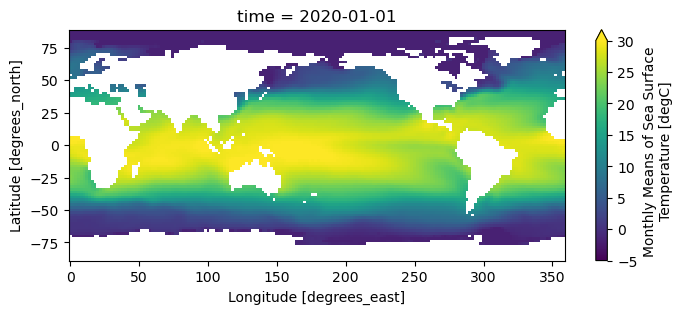

In [16]:
sst.sel(time="2020-01-01").plot(figsize=(8, 3), cmap="viridis", vmin = -5, vmax = 30)


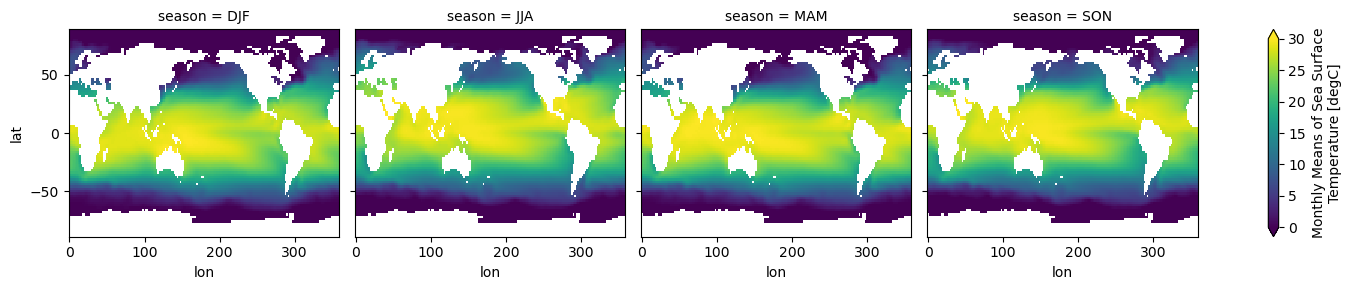

In [19]:
seasonal_mean.sst.plot( col = "season", figsize=(15, 3), vmin=0, vmax=30)


### 1.4 matplotlib subplots, cartopy, and cmocean

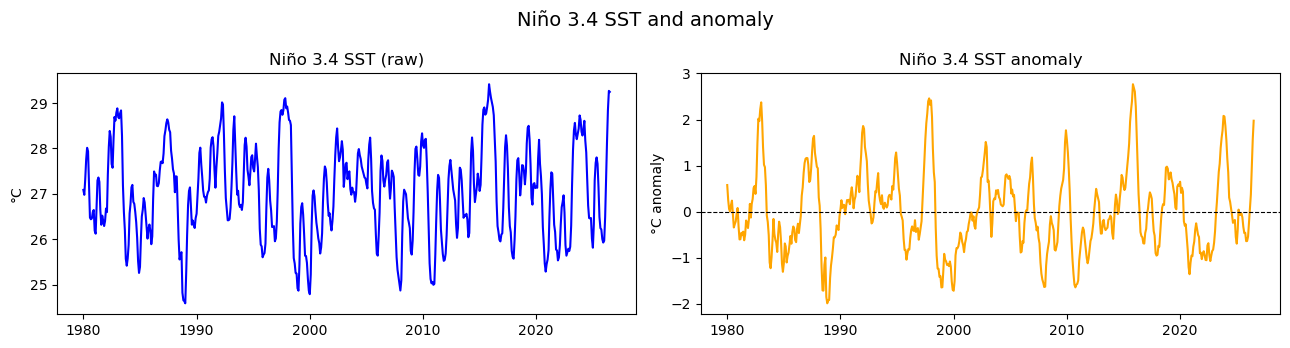

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

#nino34_index.plot(ax=axes[0])
# or 
axes[0].plot(nino34_index.time, nino34_index, color="blue")
axes[0].set_title("Niño 3.4 SST (raw)")
axes[0].set_ylabel("°C")

#nino34_anom.plot(ax=axes[1])
# or 
axes[1].plot(nino34_anom.time, nino34_anom, color="orange")
axes[1].axhline(0, color="k", lw=0.8, linestyle="--")
axes[1].set_title("Niño 3.4 SST anomaly")
axes[1].set_ylabel("°C anomaly")

plt.suptitle("Niño 3.4 SST and anomaly", fontsize=14)
plt.tight_layout()
plt.show()

### Challenge: Hovmöller diagram of the equatorial Pacific

A **Hovmöller diagram** plots one spatial dimension against time in a single 2-D image. For ENSO,
the classic version plots *longitude* (across the equatorial Pacific) against *time*, colored
by SST anomaly.

**Your task:** reproduce something like [this reference Hovmöller diagram](https://cdn.serc.carleton.edu/images/introgeo/teachingwdata/EnsoImage.gif), other datasets (SSH?) are welcome!

In [21]:
#sst_climatology = sst.groupby("time.month").mean("time")
#sst_anom = sst.groupby("time.month") - sst_climatology

# 2N-2S, 140E-100W (100W = 360-100 = 260 on our 0-360 lon grid)
#box = sst_anom.sel(lat=slice(2, -2), lon=slice(140, 260))
#lon_mean = box.mean(dim="lat")   # average over latitude

#fig, ax = plt.subplots(figsize=(6, 10))
#lon_mean.plot(
#    x="lon", y="time", ax=ax,
#    cmap=cmocean.cm.balance, vmin=-3, vmax=3,
#    cbar_kwargs={"label": "SST anomaly (°C)"},
#)
#ax.invert_yaxis()   # time increases downward
#ax.set_title("Hovmöller: Equatorial Pacific SST anomaly (2°N-2°S)")
#ax.set_ylabel("Time")
#ax.set_xlabel("Longitude (°E)")
#plt.tight_layout()
#plt.show()

# `pandas` is a library for working with tabular data. 
### It has a data structure called a `DataFrame` that is similar to a spreadsheet or SQL table. You can convert an xarray `Dataset` to a pandas `DataFrame` using the `to_dataframe()` method.


In [22]:
# you can convert to a xarray dataset or a pandas dataframe like so
sst_df = sst.to_dataframe().reset_index()
sst_df

,time,lat,lon,sst
0,1980-01-01,88.0,0.0,-1.8
1,1980-01-01,88.0,2.0,-1.8
2,1980-01-01,88.0,4.0,-1.8
3,1980-01-01,88.0,6.0,-1.8
4,1980-01-01,88.0,8.0,-1.8
...,...,...,...,...
8955175,2026-07-01,-88.0,350.0,NaN
8955176,2026-07-01,-88.0,352.0,NaN
8955177,2026-07-01,-88.0,354.0,NaN
8955178,2026-07-01,-88.0,356.0,NaN


**Note** : Pandas doesn't carry variable metadata like units the way xarray does these are lost in the conversion to a dataframe.


In [ ]:
## to add  back the units
units = ds_sst.sst.attrs["units"]   # or the shorthand ds.sst.units
sst_df.attrs["units"] = ds_sst.sst.attrs["units"]
sst_df.attrs["units"]  

### Reading a second format: chlorophyll (CSV) with `pandas`



In [23]:
# event-based chlorophyll data (CCE LTER), one row per sampling event
chl_df = pd.read_csv("/Users/sophiewynn/Desktop/lesson plans/MathWorkShop/california_current_ecosystem_lter - california_current_ecosystem_lter.csv")
#chl_df["Date PST"] = pd.to_datetime(chl_df["Date PST"], format="%m/%d/%y")
chl_df.head()

,Event,Date PST,Time PST,Latitude,Longitude,T Chla (µg/L),Chla > 3µm (µg/L),Chla < 3µm (%),Chla > 3µm (%),Sample Temp (C),Sea Surface Temp (C),Station Depth (m),Sample Depth (m),Program,Water Collection School,Sample Analysis School,Number of Students
0,2,1/17/06,10:00:00,33.434833,-117.699833,2.123682,0.914921,56.918160,43.081840,NaN,15.222222,36.57600,10.0,LS,Concordia Elementary,Concordia Elementary,33.0
1,3,1/19/06,7:00:00,33.434667,-117.700167,0.632127,0.292269,53.764211,46.235789,13.0,14.222222,36.75888,10.0,SS,Loma Linda Academy,Loma Linda Academy,33.0
2,6,2/2/06,NaN,33.433317,-117.701333,4.110691,2.438282,40.684386,59.315614,15.0,15.722222,34.74720,10.0,LS,NaN,Edison Elementary,31.0
3,7,2/14/06,NaN,33.434167,-117.699167,3.910939,1.683455,56.955220,43.044780,15.0,15.000000,34.74720,10.0,LS,NaN,NaN,39.0
4,8,2/15/06,NaN,33.451167,-117.730833,3.553488,1.934443,45.562130,54.437870,15.0,14.722222,32.91840,10.0,LS,NaN,Claremont College,22.0


### quick pandas dataframe commands


In [24]:
chl_df.describe()

,Event,Latitude,Longitude,T Chla (µg/L),Chla > 3µm (µg/L),Chla < 3µm (%),Chla > 3µm (%),Sample Temp (C),Sea Surface Temp (C),Station Depth (m),Sample Depth (m),Number of Students
count,1397.000000,1396.000000,1395.000000,1396.000000,1396.000000,1396.000000,1396.000000,1375.000000,1299.000000,1379.000000,1396.000000,1331.000000
mean,770.677881,33.438768,-117.711370,2.212214,1.120703,58.825441,41.174559,17.045193,18.034001,42.383293,10.007163,32.639369
std,432.977341,0.018574,0.027406,3.007087,2.066404,20.045586,20.045586,2.751639,3.063147,27.469485,0.567917,8.109258
min,2.000000,33.367667,-118.178500,0.029130,0.004280,-3.718651,2.538071,8.400000,-16.333333,12.192000,5.000000,8.000000
25%,397.000000,33.432333,-117.723000,0.685544,0.193620,45.566563,25.109611,15.050000,15.888889,36.576000,10.000000,28.000000
50%,770.000000,33.436842,-117.706767,1.302697,0.454757,62.148373,37.851627,17.000000,17.777778,36.576000,10.000000,32.000000
75%,1148.000000,33.445000,-117.696667,2.536226,1.155642,74.890389,54.433437,18.900000,20.083333,40.000000,10.000000,38.000000
max,1511.000000,33.780333,-117.623833,37.017799,25.522492,97.461929,103.718651,28.000000,26.111111,629.107200,30.000000,61.000000


### how to slice in pandas with csv

In [25]:
# Date PST reads in as plain text you can convert it to this format like so 
chl_dates = pd.to_datetime(chl_df["Date PST"], format="%m/%d/%y")

# slice the dataframe to a specific date range
recent_chl = chl_df[(chl_dates >= "2015-01-01") & (chl_dates <= "2020-12-31")]

# pandas also lets you slice by partial date strings once the date is the index:
# set the index once, then slice the whole frame
chl_indexed = chl_df.set_index(chl_dates)
chl_indexed.loc["2016"]        # every sample in 2016
chl_indexed.loc["2016-06"]     # every sample in June 2016

,Event,Date PST,Time PST,Latitude,Longitude,T Chla (µg/L),Chla > 3µm (µg/L),Chla < 3µm (%),Chla > 3µm (%),Sample Temp (C),Sea Surface Temp (C),Station Depth (m),Sample Depth (m),Program,Water Collection School,Sample Analysis School,Number of Students
Date PST,,,,,,,,,,,,,,,,,
2016-06-06,886,6/6/16,10:30:00,33.436167,-117.704000,2.092092,0.337434,83.870968,16.129032,16.0,17.777778,36.576,10.0,LS,San Juan Elementary,San Juan Elementary,42.0
2016-06-08,887,6/8/16,13:30:00,33.449667,-117.705500,1.077259,0.318875,70.399374,29.600626,17.9,18.500000,NaN,10.0,LS,San Juan Elementary,Reh Elementary,46.0
2016-06-10,888,6/10/16,10:30:00,33.442667,-117.723000,5.879792,1.834799,68.794835,31.205165,17.0,17.777778,36.576,10.0,PUB,Reh Elementary,Reh Elementary,36.0
2016-06-13,889,6/13/16,10:30:00,33.433867,-117.700133,2.252374,0.780317,65.355805,34.644195,18.5,18.722222,38.100,10.0,LS,Reh Elementary,Washington -,32.0


### how to group by month and average in pandas

<Axes: title={'center': 'Mean chlorophyll by month, \n all years and locations'}, xlabel='month', ylabel='Mean T Chla (µg/L)'>

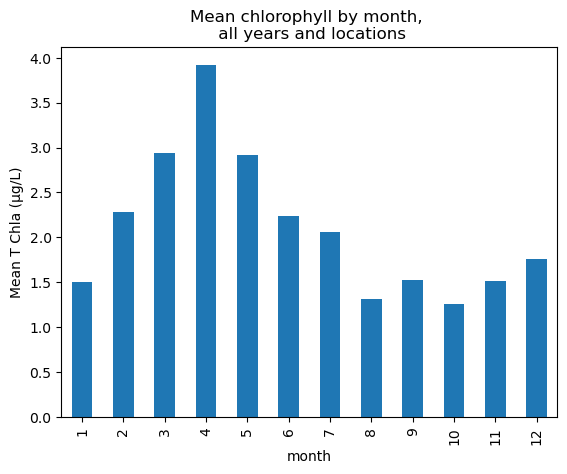

In [27]:
# a group by example in pandas chrolphyll

# same idea as xarray's groupby("time.month") climatology earlier, but in pandas
# group every sample by its month (across all years) and average
monthly_chl = chl_df.groupby(chl_dates.dt.month)["T Chla (µg/L)"].mean()
monthly_chl.index.name = "month"
monthly_chl.plot(kind="bar", ylabel="Mean T Chla (µg/L)", title="Mean chlorophyll by month, \n all years and locations")


### The pandas.cut function turns continuous numeric data into discrete interval bins, which makes it easy to group and summarize data.

In [28]:
chl_df["Station Depth Bin"] = pd.cut(
    chl_df["Station Depth (m)"],
    bins=[0, 20, 40, 100, chl_df["Station Depth (m)"].max()],
    labels=["<20m", "20-40m", "40-100m", ">100m"],
)

chl_df.groupby("Station Depth Bin")["T Chla (µg/L)"].mean()

/var/folders/9t/9gfwlwbs0vxb1xc247fmxzk80000gn/T/ipykernel_8223/72257899.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chl_df.groupby("Station Depth Bin")["T Chla (µg/L)"].mean()


Station Depth Bin
<20m       1.611269
20-40m     2.244187
40-100m    2.221003
>100m      1.140293
Name: T Chla (µg/L), dtype: float64

---
## Part 2 — Mapping with `cartopy` + `cmocean

### 2.1 Real maps: `cartopy` for projections, `cmocean` for color

**Why `cmocean` instead of a default colormap:** `cmocean`'s palettes were built specifically for
ocean data and are *perceptually uniform* 

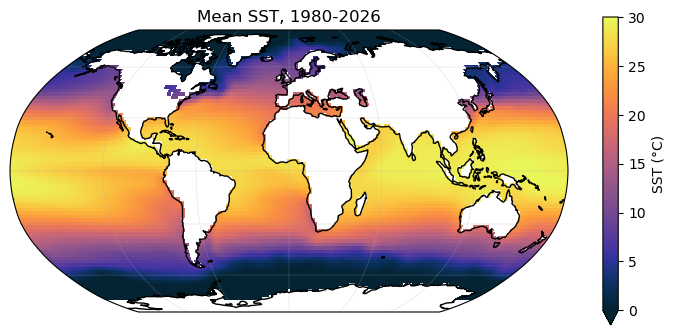

In [30]:
fig = plt.figure(figsize=(9, 4)) # defines the figure size, and figure
ax = plt.axes(projection=ccrs.Robinson()) # add central_longitude=180 if you want the Pacific in the center

sst.mean("time").plot(
    ax=ax,   transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.thermal, cbar_kwargs={"label": "SST (°C)"}, vmin=0, vmax=30,
)
ax.coastlines()
ax.gridlines(linewidth=0.3, alpha=0.5)   # no draw_labels — avoids the shapely codepath
ax.set_title("Mean SST, 1980-2026")
plt.show() 

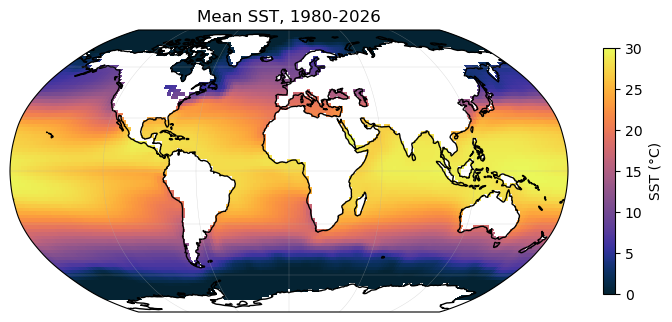

In [31]:
# you can also do this using matplotlib directly, without xarray's `.plot()` wrapper
fig = plt.figure(figsize=(9, 4)) # defines the figure size, and figure
ax = plt.axes(projection=ccrs.Robinson()) # add central_longitude=180 if you want the Pacific in the center

sst_mean = sst.mean("time")
lon2d, lat2d = np.meshgrid(sst_mean.lon, sst_mean.lat)  # turn the 1-D lon/lat vectors into a 2-D
                                                         
mesh = ax.pcolormesh(
    lon2d, lat2d, sst_mean.values,
    cmap=cmocean.cm.thermal, transform=ccrs.PlateCarree(), vmin=0, vmax=30
)
plt.colorbar(mesh, ax=ax, label="SST (°C)", shrink=0.8)

ax.coastlines()
ax.gridlines(linewidth=0.3, alpha=0.5)   
ax.set_title("Mean SST, 1980-2026")
plt.show()

`transform=ccrs.PlateCarree()`and  `projection=` to (`Robinson()`) adapts the plot to map to a nicer projection


### 2.1b Point data with `geopandas`

Not everything in this workshop is a `(time, lat, lon)` grid. The chlorophyll table we read with
`pandas` is *point* data, one row per sampling event. Here `geopandas` adds a `geometry` column to a regular
`DataFrame` and understands coordinate reference systems (CRS), so it plots straight onto a
`cartopy` axes the same way the gridded SST field did above.

As an example we can color each point by its own chlorophyll value, using
`cmocean.cm.algae` 

In [37]:
# one point per sampling event  each row has its own lat/lon
chl_geo = chl_df.dropna(subset=["Latitude", "Longitude"])   # drop first, then build geometry from
                                                              # the SAME filtered frame
                                                              # (some rows are missing coordinates)
gdf_events = gpd.GeoDataFrame(
    chl_geo,
    geometry=gpd.points_from_xy(chl_geo["Longitude"], chl_geo["Latitude"]),
    #crs="EPSG:4326",   # plain lat/lon -- same CRS cartopy's PlateCarree() expects
)
gdf_events[["Event", "Date PST", "Latitude", "Longitude", "T Chla (µg/L)", "geometry"]].head()

,Event,Date PST,Latitude,Longitude,T Chla (µg/L),geometry
0,2,1/17/06,33.434833,-117.699833,2.123682,POINT (-117.69983 33.43483)
1,3,1/19/06,33.434667,-117.700167,0.632127,POINT (-117.70017 33.43467)
2,6,2/2/06,33.433317,-117.701333,4.110691,POINT (-117.70133 33.43332)
3,7,2/14/06,33.434167,-117.699167,3.910939,POINT (-117.69917 33.43417)
4,8,2/15/06,33.451167,-117.730833,3.553488,POINT (-117.73083 33.45117)


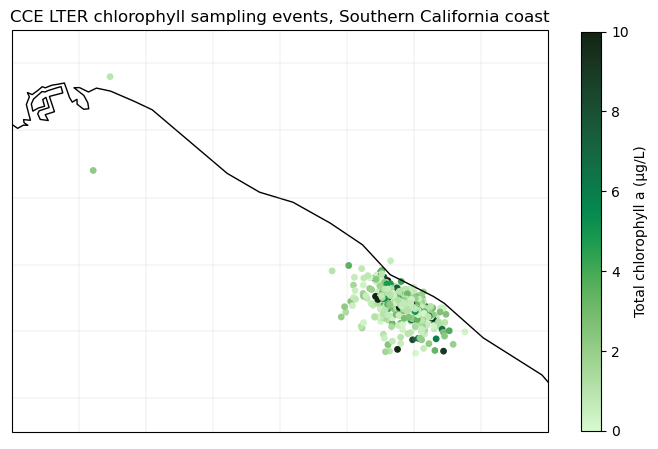

In [38]:
# CCE LTER sampling events, colored by total chlorophyll 
fig = plt.figure(figsize=(7, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-118.3, -117.5, 33.25, 33.85], crs=ccrs.PlateCarree())  # nearshore Orange County

sc = ax.scatter(
    gdf_events.geometry.x, gdf_events.geometry.y,
    c=gdf_events["T Chla (µg/L)"], cmap=cmocean.cm.algae,
    s=15, vmin=0, vmax=10, transform=ccrs.PlateCarree(),
)
plt.colorbar(sc, ax=ax, label="Total chlorophyll a (µg/L)", shrink=0.7)

ax.coastlines()
ax.gridlines(linewidth=0.3, alpha=0.5)
ax.set_title("CCE LTER chlorophyll sampling events, Southern California coast")
plt.tight_layout()
plt.show()

The same two lines (`gpd.points_from_xy` + `GeoDataFrame(...)`) could work for  for tide gauge stations, mooring locations etc.

### Extra time: choose your own adventure

Pick a dataset from the workshop, if it is `sst` `chl_df` please pick your own slice, group, or filter of it. Make a plot of whatever you're
could be curious about.

